In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

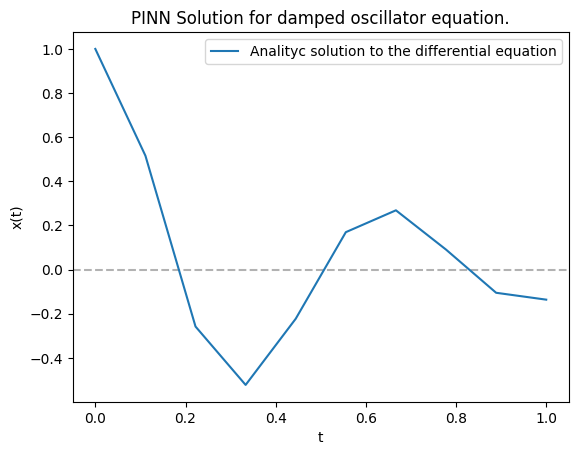

In [2]:
# sampled data generation
t_sample = 1*torch.linspace(0, 1, 10).reshape(-1, 1)
t_sample.requires_grad = False

# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# data
root = torch.sqrt(torch.tensor([ZETTA**2 - 1], dtype=torch.cfloat))
x_sample = X0*torch.exp(-W*ZETTA*t_sample)*(torch.cosh(W*root*t_sample) + (ZETTA/root)*torch.sinh(W*root*t_sample))
# get rid of the complex values remaning due to numerical approximations
x_sample = x_sample.real

import matplotlib.pyplot as plt
plt.figure()
plt.axhline(y = 0, color = 'k', linestyle = '--', alpha=0.3) 
plt.plot(t_sample.detach().numpy(), x_sample.detach().numpy(), label="Analityc solution to the differential equation")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

# Unsupervised data generation
t = torch.rand(100, 1)  # In the same interval as the sampled data.
t.requires_grad = True


In [3]:
# define a classic model
# Define the PINN model
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)


# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def damped_oscillatior_loss(model, t):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    x_0 = model(t_0)
    initial_conditions = (x_0 - X0)**2
    x_t_0 = torch.autograd.grad(x_0, t_0, grad_outputs=torch.ones_like(x_0), create_graph=True)[0]
    initial_conditions_der = (x_t_0 - X_T_0)**2
    return torch.mean(f) + \
        torch.mean(initial_conditions) + \
        torch.mean(initial_conditions_der)

In [4]:
# Create PINN model
nn_model = NN()
pinn_model = PINN()

nn_optimizer = optim.Adam(params=nn_model.parameters(), lr=1e-4)
pinn_optimizer = optim.Adam(params=pinn_model.parameters(), lr=1e-3)

# loss tracking
nn_losses = []
pinn_losses = []

# Training loop
epochs = 60000
for epoch in range(epochs):
    # Compute the losses
    x_sample_estimate = nn_model(t_sample)
    nn_loss = nn.MSELoss()(x_sample_estimate, x_sample)

    # zero grad
    nn_optimizer.zero_grad()
    
    # Backprop
    nn_loss.backward()
    nn_losses.append(torch.log(nn_loss).item())
    nn_optimizer.step()
    
    # compute loss
    x_sample_estimate = nn_model(t_sample)
    pinn_loss = damped_oscillatior_loss(pinn_model, t) + nn.MSELoss()(t_sample, x_sample_estimate)

    # zero_grad
    pinn_optimizer.zero_grad()

    # Backprop
    pinn_loss.backward()
    pinn_losses.append(torch.log(pinn_loss).item())
    pinn_optimizer.step()
    
    if epoch % 1000 == 0:
        print("NN loss")
        print(f"    Epoch [{epoch}/{epochs}], Loss: {nn_loss.item()}")
        print("PINN loss")
        print(f"    Epoch [{epoch}/{epochs}], Loss: {pinn_loss.item()}")
        print("====================================================")


/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:251: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


NN loss
    Epoch [0/60000], Loss: 0.19141021370887756
PINN loss
    Epoch [0/60000], Loss: 58.83837890625
NN loss
    Epoch [1000/60000], Loss: 0.020418768748641014
PINN loss
    Epoch [1000/60000], Loss: 1.5157744884490967
NN loss
    Epoch [2000/60000], Loss: 0.001251974143087864
PINN loss
    Epoch [2000/60000], Loss: 1.632298469543457
NN loss
    Epoch [3000/60000], Loss: 0.00046543931239284575
PINN loss
    Epoch [3000/60000], Loss: 1.5609475374221802
NN loss
    Epoch [4000/60000], Loss: 0.000130038897623308
PINN loss
    Epoch [4000/60000], Loss: 1.5760018825531006
NN loss
    Epoch [5000/60000], Loss: 5.446356226457283e-05
PINN loss
    Epoch [5000/60000], Loss: 1.5595743656158447
NN loss
    Epoch [6000/60000], Loss: 1.4358705584527343e-06
PINN loss
    Epoch [6000/60000], Loss: 1.561525583267212
NN loss
    Epoch [7000/60000], Loss: 1.4031253385837772e-06
PINN loss
    Epoch [7000/60000], Loss: 1.5623576641082764
NN loss
    Epoch [8000/60000], Loss: 8.16973965811485e-07
PIN

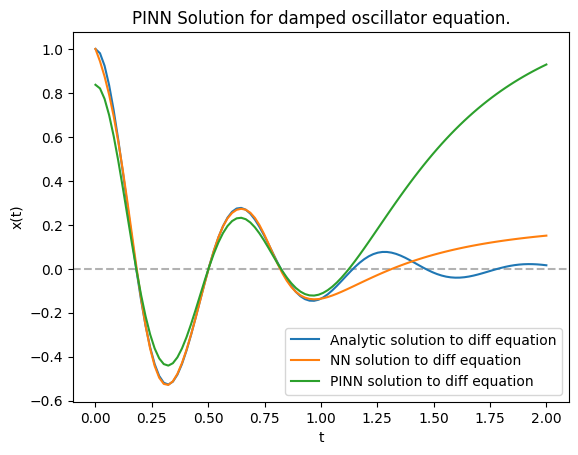

In [5]:
# sampled data generation
t_sample = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
t_sample.requires_grad = False

# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# data
root = torch.sqrt(torch.tensor([ZETTA**2 - 1], dtype=torch.cfloat))
x_sample = X0*torch.exp(-W*ZETTA*t_sample)*(torch.cosh(W*root*t_sample) + (ZETTA/root)*torch.sinh(W*root*t_sample))
# get rid of the complex values remaning due to numerical approximations
x_sample = x_sample.real



# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
nn_x_test = nn_model(t_test)
pinn_x_test = pinn_model(t_test)

# Plot the results
import matplotlib.pyplot as plt
plt.figure()
plt.axhline(y = 0, color = 'k', linestyle = '--', alpha=0.3) 
plt.plot(t_sample.detach().numpy(), x_sample.detach().numpy(), label="Analytic solution to diff equation")
plt.plot(t_test.detach().numpy(), nn_x_test.detach().numpy(), label="NN solution to diff equation")
plt.plot(t_test.detach().numpy(), pinn_x_test.detach().numpy(), label="PINN solution to diff equation")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

It seems that the PINN takes a lot more time to converge, but data can be
artificially added to the domain of the NN to extrapolate the aproximation's
domain. It also appears that the PINN gets pretty close to the original curve.
(Even without sample data).

With sample data, the convergence will probably take more.

Yep it seems that it takes much more time.